# Height correction of Holomonitor data

Here, we compare the mean height of datasets with and without reference points, and determine the correction shift of datasets without reference points

In [1]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import least_squares


sys.path.append("scripts/utils/")
from file_operations import *
from SegmentedCells  import SegmentedCells
from Microscopes     import Holomonitor

In [2]:
def poly0(p, x):
    return p[0]

def poly2(p, x):
    return p[0] + p[1] * x + p[2] * x**2

In [3]:
_2DQPI = Holomonitor()

In [4]:
data_path = "../../../../hdd_data/silja/Monolayers/"

datasets_2D = [
    "MDCK_20240301_B1-4",
    "MDCK_20240301_B2-2",
    "MDCK_20240301_B2-6",
    "MDCK_20240317_B1-1",
    "MDCK_20240319_A1-9",
    "MDCK_20240319_A1-13",
    "MDCK_20240319_A1-16",
    "MDCK_20240319_A1-18",
    "MDCK_20240319_B1-11",
    "MDCK_20240516_A2-1", 
    "MDCK_20240516_A2-7",
    "MDCK_20240516_B1-9",
    "MDCK_20240516_B1-13",
    "MDCK_20240516_B1-22"
]

colors = ['orange',
          'b', 'b',
          'g',
          'r', 'r', 'r', 'r',
          'm',
          'k', 'k',
          'c', 'k', 'k']

In [5]:
hmean_2D     = []
densities_2D = []

for dataset in datasets_2D:

    # load data
    config = json.load(open(f"configs/{dataset}.json"))
    stack  = load_stack(f"{data_path}height_fields/raw/{dataset}/", config, data_type="cells")
    cells  = SegmentedCells(f"{data_path}cell_features/raw/{dataset}_cells.p")

    # Compute mean height of monolayer
    hmean_tmp = np.array([np.mean(frame[frame > 0]) for frame in stack])

    hmean_2D.append( hmean_tmp )
    densities_2D.append(cells.density)


State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240301_B1-4_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240301_B2-2_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240301_B2-6_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240317_B1-1_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240319_A1-9_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240319_A1-13_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240319_A1-16_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240319_A1-18_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240319_B1-11_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK

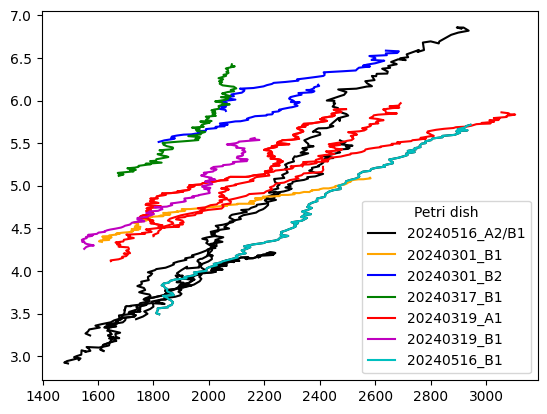

In [6]:

plt.figure()

for h, rho in zip(hmean_2D[-5:],
                  densities_2D[-5:]):
    plt.plot(rho, h, '-', c='k')

plt.plot(densities_2D[-1], hmean_2D[-1], 'k',      label="20240516_A2/B1")
plt.plot(densities_2D[0],  hmean_2D[0],  'orange', label="20240301_B1")
plt.plot(densities_2D[1],  hmean_2D[1],  'b',      label="20240301_B2")
plt.plot(densities_2D[2],  hmean_2D[2],  'b')
plt.plot(densities_2D[3],  hmean_2D[3],  'g',      label="20240317_B1")
plt.plot(densities_2D[4],  hmean_2D[4],  'r',      label="20240319_A1")

for h, rho in zip(hmean_2D[4:-6],
                  densities_2D[4:-6]):
    plt.plot(rho, h, '-', c='r')

plt.plot(densities_2D[8], hmean_2D[8], 'm', label="20240319_B1")
plt.plot(densities_2D[11], hmean_2D[11], 'c', label="20240516_B1")

plt.legend(title="Petri dish")

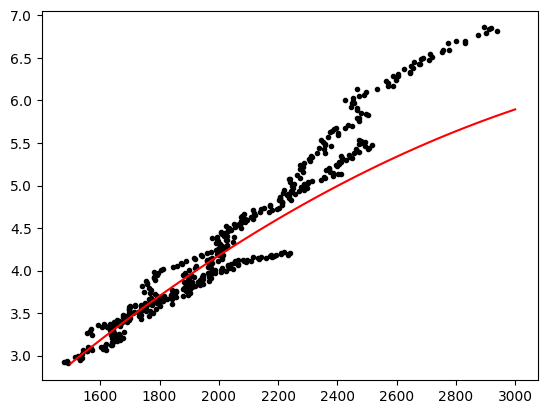

In [7]:
rho_reference = np.concatenate([densities_2D[9],
                                densities_2D[10],
                                densities_2D[12],
                                densities_2D[13]])

h_reference = np.concatenate([hmean_2D[9],
                              hmean_2D[10],
                              hmean_2D[12],
                              hmean_2D[13]])

density = np.linspace(1500, 3000, 100)

mask = (rho_reference > 1600) * (rho_reference < 2225)
param_reference = np.polyfit(rho_reference[mask], h_reference[mask], 2, w=1/rho_reference[mask])[::-1]
plt.plot(rho_reference, h_reference, 'k.')
plt.plot(density, poly2(param_reference, density), 'r')


In [8]:
shifts = []

# 20240301_B1
fit   = poly2(param_reference, densities_2D[0])
shift = np.polyfit(densities_2D[0], hmean_2D[0] - fit, 0, w=1/densities_2D[0])[0]
shifts.append(shift)

# 20240301_B2
rho_tmp = np.concatenate([densities_2D[1],
                          densities_2D[2]])
h_tmp   = np.concatenate([hmean_2D[1],
                          hmean_2D[2]])

fit   = poly2(param_reference, rho_tmp)
shift = np.polyfit(rho_tmp, h_tmp - fit, 0, w=1/rho_tmp)[0]
shifts.append(shift)
shifts.append(shift)

# 20240317_B1
fit   = poly2(param_reference, densities_2D[3])
shift = np.polyfit(densities_2D[3], hmean_2D[3] - fit, 0, w=1/densities_2D[3])[0]
shifts.append(shift)


# 20240319_A1
rho_tmp = np.concatenate([densities_2D[4],
                          densities_2D[5],
                          densities_2D[6],
                          densities_2D[7]])
h_tmp   = np.concatenate([hmean_2D[4],
                          hmean_2D[5],
                          hmean_2D[6],
                          hmean_2D[7],])

fit   = poly2(param_reference, rho_tmp)
shift = np.polyfit(rho_tmp, h_tmp - fit, 0, w=1/rho_tmp)[0]
shifts.append(shift)
shifts.append(shift)
shifts.append(shift)
shifts.append(shift)

# 20240319_B1
fit   = poly2(param_reference, densities_2D[8])
shift = np.polyfit(densities_2D[8], hmean_2D[8] - fit, 0, w=1/densities_2D[8])[0]
shifts.append(shift)

# 20240516_B1
fit   = poly2(param_reference, densities_2D[11])
shift = np.polyfit(densities_2D[11], hmean_2D[11] - fit, 0, w=1/densities_2D[11])[0]
shifts.append(0)
shifts.append(0)
shifts.append(shift)
shifts.append(0)
shifts.append(0)

shifts

[np.float64(0.6882363819473848),
 np.float64(1.3979586046242252),
 np.float64(1.3979586046242252),
 np.float64(1.6952097290550938),
 np.float64(0.6405129957783045),
 np.float64(0.6405129957783045),
 np.float64(0.6405129957783045),
 np.float64(0.6405129957783045),
 np.float64(1.0283278459264433),
 0,
 0,
 np.float64(-0.16358479048271454),
 0,
 0]

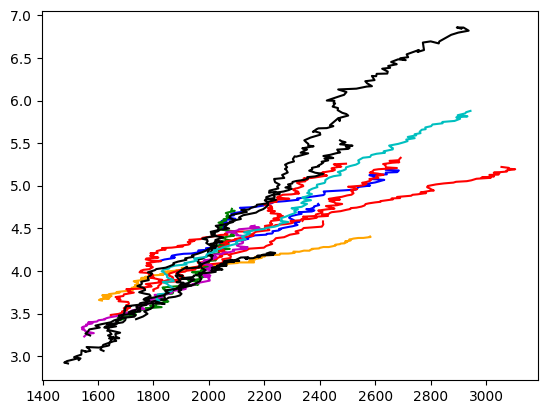

In [9]:
parameters = []
for rho, h, dh, c in zip(densities_2D,
                         hmean_2D,
                         shifts,
                         colors):
    
    plt.plot(rho, h-dh, c=c)

In [10]:
# shifts = []
# densities = np.arange(1600, 2200, 100)

# # 20240301_B1
# param = np.polyfit(densities_2D[0], hmean_2D[0], 2)[::-1]
# shift = np.polyfit(densities, poly2(param_reference, densities) - poly2(param, densities), 0)[0]
# shifts.append(shift)


# # 20240301_B2
# rho_tmp = np.concatenate([densities_2D[1],
#                           densities_2D[2]])
# h_tmp   = np.concatenate([hmean_2D[1],
#                           hmean_2D[2]])

# param = np.polyfit(rho_tmp, h_tmp, 2)[::-1]
# shift = np.polyfit(densities, poly2(param_reference, densities) - poly2(param, densities), 0)[0]
# shifts.append(shift)
# shifts.append(shift)


# # 20240317_B1
# param = np.polyfit(densities_2D[3], hmean_2D[3], 2)[::-1]
# shift = np.polyfit(densities, poly2(param_reference, densities) - poly2(param, densities), 0)[0]
# shifts.append(shift)


# # 20240319_A1
# rho_tmp = np.concatenate([densities_2D[4],
#                           densities_2D[5],
#                           densities_2D[6],
#                           densities_2D[7]])
# h_tmp   = np.concatenate([hmean_2D[4],
#                           hmean_2D[5],
#                           hmean_2D[6],
#                           hmean_2D[7],])

# param = np.polyfit(rho_tmp, h_tmp, 2)[::-1]
# shift = np.polyfit(densities, poly2(param_reference, densities) - poly2(param, densities), 0)[0]
# shifts.append(shift)
# shifts.append(shift)
# shifts.append(shift)
# shifts.append(shift)


# # 20240319_B1
# param = np.polyfit(densities_2D[8], hmean_2D[8], 2)[::-1]
# shift = np.polyfit(densities, poly2(param_reference, densities) - poly2(param, densities), 0)[0]
# shifts.append(shift)


# # 20240516_B1
# param = np.polyfit(densities_2D[11], hmean_2D[11], 2)[::-1]
# shift = np.polyfit(densities, poly2(param_reference, densities) - poly2(param, densities), 0)[0]
# shift = np.polyfit(densities_2D[11], hmean_2D[11] - fit, 0, w=1/densities_2D[11])[0]
# shifts.append(0)
# shifts.append(0)
# shifts.append(shift)
# shifts.append(0)
# shifts.append(0)


# shifts

In [11]:
# parameters = []
# for rho, h, dh, c in zip(densities_2D,
#                          hmean_2D,
#                          shifts,
#                          colors):
    
#     plt.plot(rho, h+dh, c=c)